# Examine the set of 3-block light curves
"Bump" hunting. Isolate those with long start and end blocks, look for those
where the starting and ending fluxes are close.

In [1]:
%reset -f

from importlib import reload
from pylib import agn_steps; reload(agn_steps)
from pylib.agn_steps import (VarDB, set_theme, show_date,  association_breakdown, ThreeBlocks,
                             show, show_fig, np, pd, plt, hist_bbvar, capture_hide, lcsetup, bb_display)
from wtlike import WtLike
set_theme(['dark']); show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-03-27 13:24</h5>

In [2]:
self =  ThreeBlocks(margin=700)
show(f'Associations for the {len(self.df)} three-block sources:')
show(association_breakdown(self.df))

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x70d7da198be0>

Associations for the 489 three-block sources:

,bll,fsrq,bcu,psr,other,unid
,132,45,146,18,13,135


## Bump flux property

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x70d7dfd0beb0>
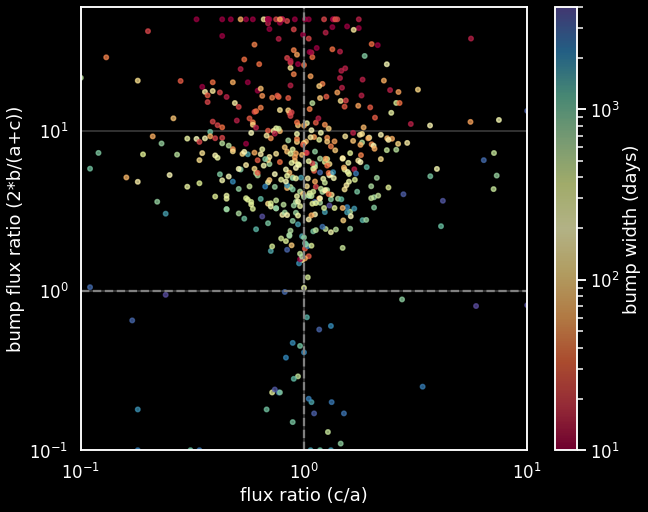

Notes:
* Most bumps are positive, flux ratio>2 or so 
* large bumps >10 are short--flares or from nearby flaring sources
* after/before flux ratio close to one
* The few negative bumps are long. 

In [3]:
show(f"""## Bump flux property""")
show_fig(self.bump_plot)
show("""\
Notes:
* Most bumps are positive, flux ratio>2 or so 
* large bumps >10 are short--flares or from nearby flaring sources
* after/before flux ratio close to one
* The few negative bumps are long. 
""")

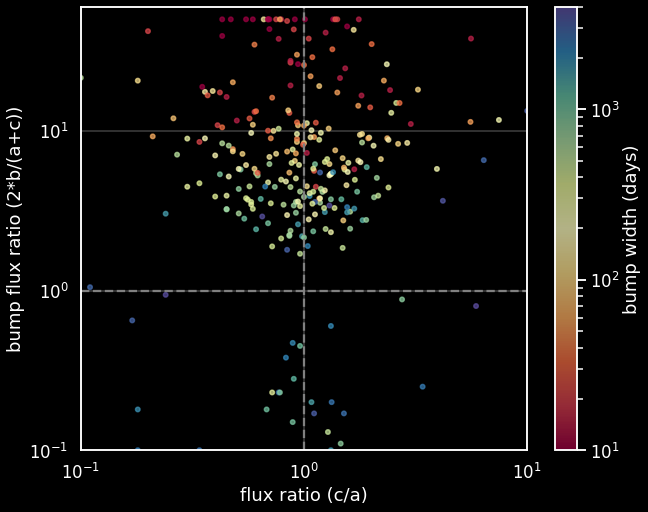

In [4]:
self.bump_plot('association in ["bll","bcu"]');

In [5]:
show(f""" Select sources with {(bump_cut:="2<bump_ratio<10 & 0.5<flux_ratio<2")}""")
df_bcut = self.df.query(bump_cut)
show(association_breakdown(df_bcut,'bump cut'))

Select sources with 2<bump_ratio<10 & 0.5<flux_ratio<2

,bll,fsrq,bcu,psr,other,unid
bump cut,68,16,60,6,7,58


In [6]:
df_bcut.query('association=="bll"').sort_values('ts', ascending=False)['ts bbvar variability flux_ratio bump_ratio bump_width'.split()]

,ts,bbvar,variability,flux_ratio,bump_ratio,bump_width
4FGL J0423.9+4150,3447,21,12.800000,1.13,4.47,21.0
4FGL J0844.9-5458,1999,27,20.900000,1.17,3.77,56.0
4FGL J1203.1+6031,1615,23,38.500000,1.11,5.62,28.0
4FGL J0847.0-2336,1334,21,36.400002,1.05,2.79,175.0
4FGL J1553.5-3118,1246,39,69.800003,1.25,2.43,476.0
...,...,...,...,...,...,...
4FGL J0502.5+1340,83,27,31.200001,1.12,6.19,903.0
4FGL J1042.9+0054,70,10,11.200000,0.67,4.48,2254.0
4FGL J1506.4+4331,56,23,12.800000,0.53,7.18,105.0
4FGL J1058.0+4305,54,31,31.100000,1.91,5.93,1260.0


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x70d7decb4790>

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x70d7e35fdbd0>

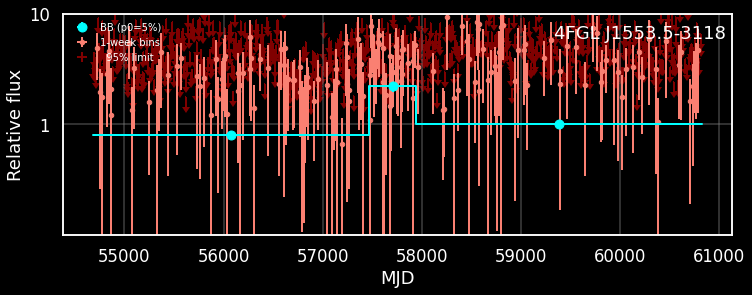

<class 'wtlike.main.WtLike'>:
        3,741,865 intervals from 54682.5 to 60821.5 for source 4FGL J1553.5-3118
        S 1788.60  B 218895.40 
LightCurve: 3 cells in view=(54682.5, 60821.5, 7), 3 fits with exposure > 35

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x70d7daac7a00>

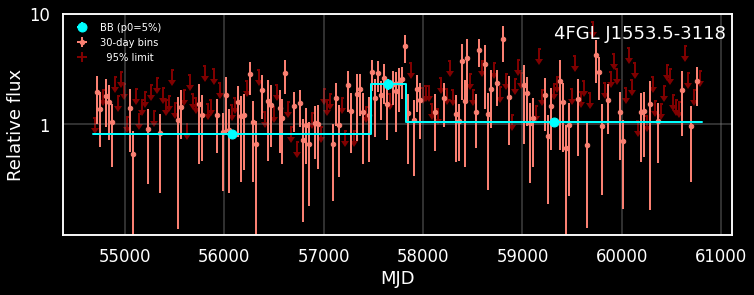

<class 'wtlike.main.WtLike'>:
        3,741,865 intervals from 54682.5 to 60802.5 for source 4FGL J1553.5-3118
        S 1788.60  B 218895.40 
LightCurve: 3 cells in view=(54682.5, 60821.5, 30), 3 fits with exposure > 150

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x70d7e0100e20>

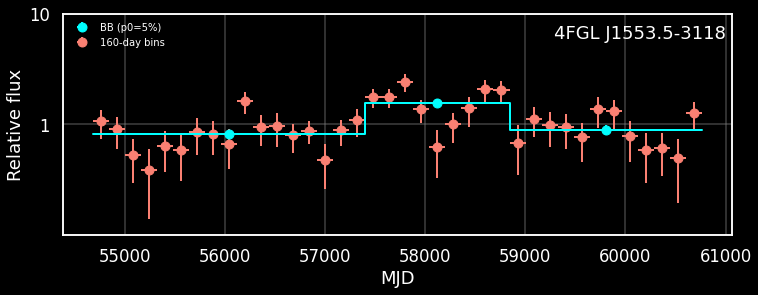

<class 'wtlike.main.WtLike'>:
        3,741,865 intervals from 54682.5 to 60762.5 for source 4FGL J1553.5-3118
        S 1788.60  B 218895.40 
LightCurve: 3 cells in view=(54682.5, 60821.5, 160), 3 fits with exposure > 800

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x70d7e357d270>

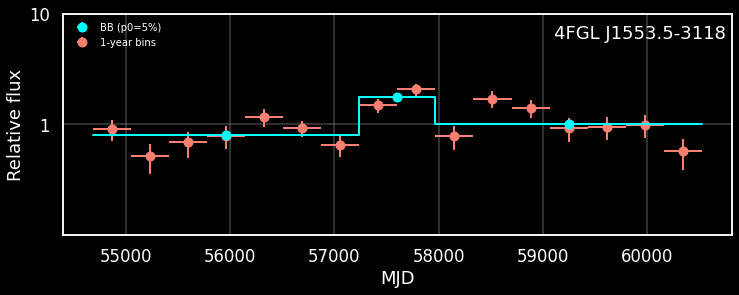

<class 'wtlike.main.WtLike'>:
        3,741,865 intervals from 54682.5 to 60526.5 for source 4FGL J1553.5-3118
        S 1788.60  B 218895.40 
LightCurve: 3 cells in view=(54682.5, 60821.5, 365.25), 3 fits with exposure > 1826.25

In [7]:
wtl = lcsetup('4FGL J1553.5-3118')  
for dt in 7, 30, 4*40, 365.25,:             
    bb = bb_display(wtl, dt); plt.show()
    show(bb)

In [8]:
def get_bb_info(bb):
    """ Return BB interval likelihood fits with 2-d (beta-free) fit also """
    
    def g2fit(cell):
        from wtlike.poisson import Poisson
        from wtlike.loglike import LogLike, Gaussian2dRep

        ts = Poisson.from_function(LogLike(cell)).ts
        r = dict(t=cell.t, tw=cell.tw, ts=round(ts,1))            
        if ts<4:
            r.update(flux=0, counts=cell.n, beta=np.nan, sig_beta=np.nan)
        else:
            r.update(Gaussian2dRep(LogLike(cell)).fit)
        return r
    try:
        df_bb = bb.fluxes['t tw ts flux errors'.split()]
        df_beta = pd.DataFrame.from_dict( 
            dict((i, g2fit(cell)) for i,cell in bb.cells.iterrows()) ,orient='index')\
                ['flux beta sig_beta'.split()]
        return pd.concat([df_bb, df_beta], axis=1)

    except Exception as e:
        raise Exception(f'bb 2-d fit failed: {e}')
        # import sys
        # print(f'SourceAnalyzer: bb 2-d fit failed: {e}', file=sys.stderr)
        # return None

show(get_bb_info(bb))


,t,tw,ts,flux,errors,flux,beta,sig_beta
0,55960.875,2556.75,353.3,0.7984,"(-0.066, 0.066)",0.786557,0.004123,0.003132
1,57604.500,730.50,298.4,1.7726,"(-0.164, 0.165)",1.774579,-0.000446,0.006045
2,59248.125,2556.75,314.0,1.0181,"(-0.085, 0.085)",1.027005,-0.002517,0.003668


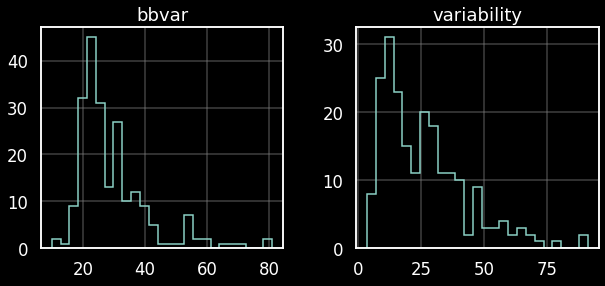

In [9]:
df_bcut.hist(['bbvar','variability'], bins=25, histtype='step', figsize=(10, 4)); plt.show()